In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit



# Dataframe

In [7]:
data_path : str = r"C:\Users\igorm\Documents\programacao\trabalho-redes-neurais\resultados_earlystop\training_results.csv"
dataframe = pd.read_csv(data_path)

Este arquivo armazena os resultados detalhados das execuções do experimento de Leis de Escala (Scaling Laws) para o dataset de doenças foliares de tomate. Cada linha representa um registro de log capturado durante o treinamento de um modelo em um determinado subconjunto de dados.

---

``Distribuição dos treinos``

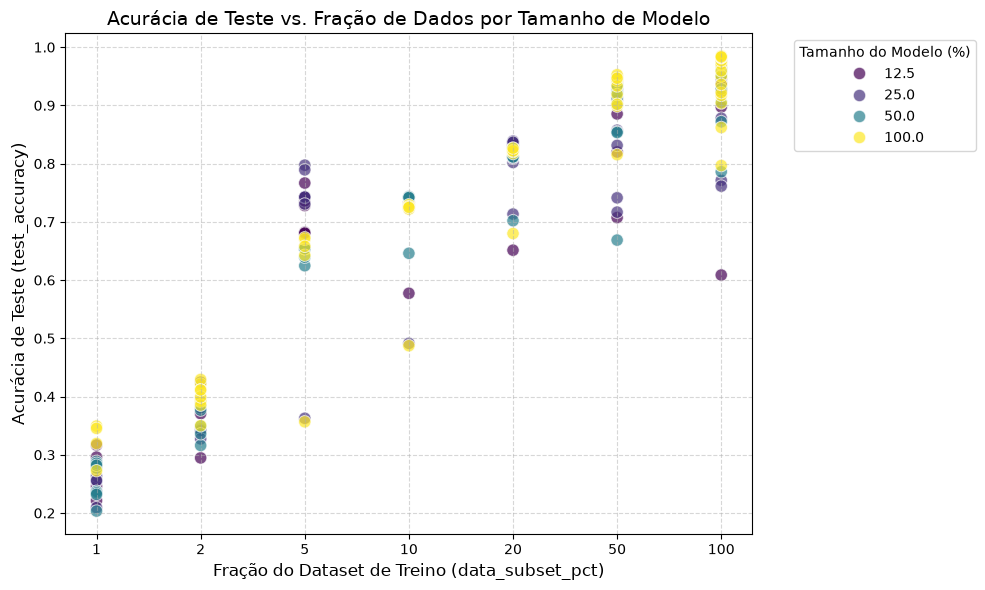

In [8]:
plt.figure(figsize=(10, 6))

dataframe['data_subset_pct_cat'] = pd.Categorical(
    dataframe['data_subset_pct'].astype(str),
    categories=[str(x) for x in sorted(dataframe['data_subset_pct'].unique())],
    ordered=True
)

sns.scatterplot(
    data=dataframe,
    x='data_subset_pct_cat',
    y='test_accuracy',
    hue='model_size_pct',
    palette='viridis',
    s=80,
    alpha=0.7
)

plt.title('Acurácia de Teste vs. Fração de Dados por Tamanho de Modelo', fontsize=14)
plt.xlabel('Fração do Dataset de Treino (data_subset_pct)', fontsize=12)
plt.ylabel('Acurácia de Teste (test_accuracy)', fontsize=12)
plt.legend(title='Tamanho do Modelo (%)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Comportamento de Escalonamento (Scaling): Observa-se que, em todas as variantes de tamanho de modelo (12.5% a 100%), o incremento no volume de dados (eixo X) resulta em um crescimento logarítmico da acurácia. A maior taxa de ganho de desempenho ocorre na transição dos estágios iniciais (1% a 20%), evidenciando que a sensibilidade da rede à entrada de novos dados é máxima em regimes de baixa amostragem.

``Media dos treinamentos``

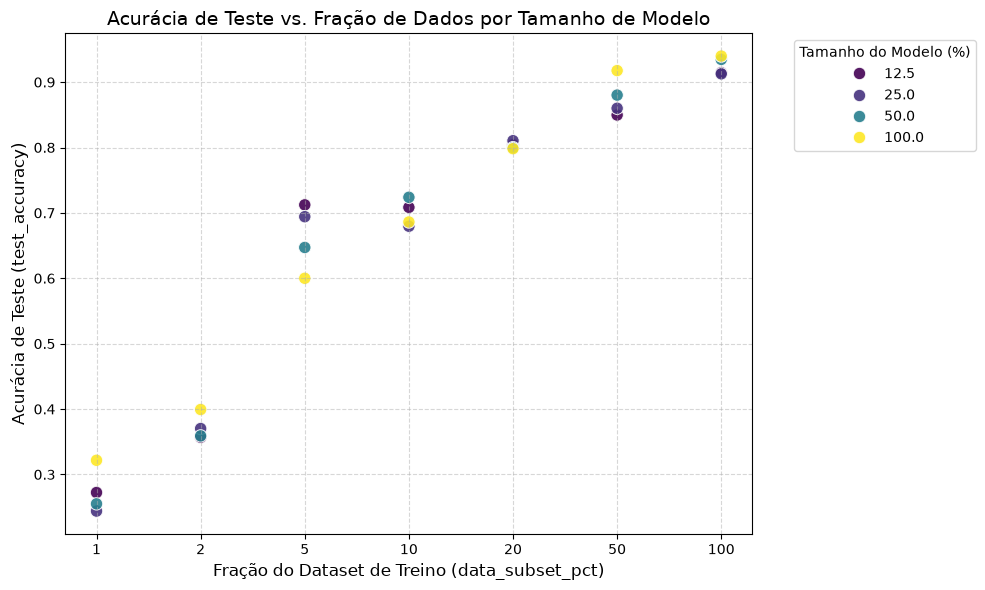

In [12]:

df_mean = dataframe.groupby(['data_subset_pct', 'model_size_pct'], as_index=False)['test_accuracy'].mean()
df_mean['data_subset_pct'] = df_mean['data_subset_pct'].astype(str)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_mean,
    x='data_subset_pct',
    y='test_accuracy',
    hue='model_size_pct',
    palette='viridis',
    s=80,
    alpha=0.9
)

plt.title('Acurácia de Teste vs. Fração de Dados por Tamanho de Modelo', fontsize=14)
plt.xlabel('Fração do Dataset de Treino (data_subset_pct)', fontsize=12)
plt.ylabel('Acurácia de Teste (test_accuracy)', fontsize=12)

plt.legend(title='Tamanho do Modelo (%)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


Convergência e Ponto de Saturação: A partir de 50% do dataset, a inclinação das curvas tende a diminuir, aproximando-se de um platô. Este fenômeno caracteriza o ponto de retorno marginal, onde o ganho de acurácia por unidade adicional de dado torna-se estatisticamente menos expressivo (< 1 ponto percentual).

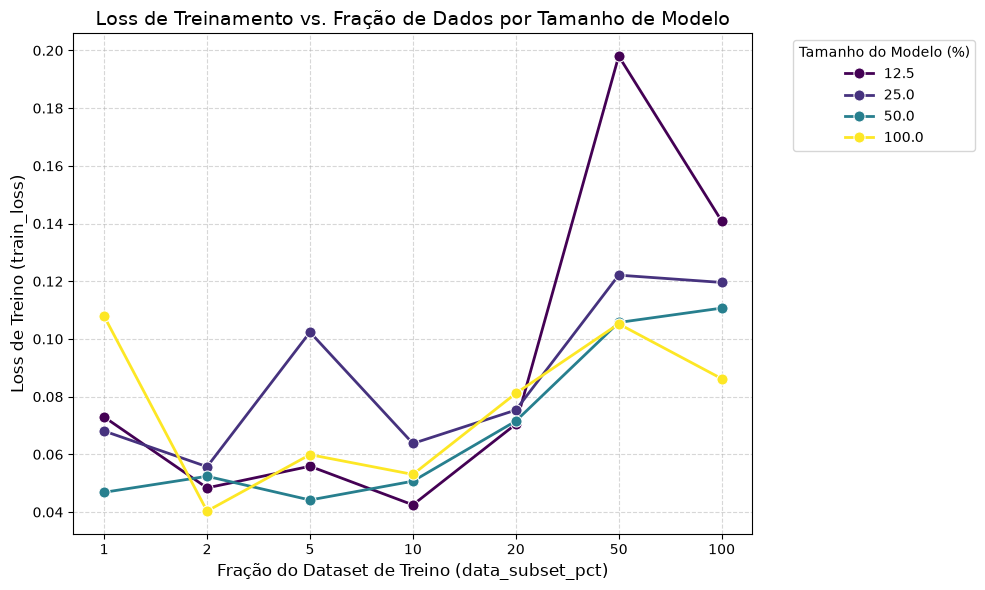

In [13]:
plt.figure(figsize=(10, 6))

dataframe['data_subset_pct_cat'] = pd.Categorical(
    dataframe['data_subset_pct'].astype(str),
    categories=[str(x) for x in sorted(dataframe['data_subset_pct'].unique())],
    ordered=True
)

sns.lineplot(
    data=dataframe,
    x='data_subset_pct_cat',
    y='train_loss',
    hue='model_size_pct',
    palette='viridis',
    linewidth=2,
    marker='o',
    markersize=8,
    errorbar=None
)

# Customizando os elementos visuais
plt.title('Loss de Treinamento vs. Fração de Dados por Tamanho de Modelo', fontsize=14)
plt.xlabel('Fração do Dataset de Treino (data_subset_pct)', fontsize=12)
plt.ylabel('Loss de Treino (train_loss)', fontsize=12)
plt.legend(title='Tamanho do Modelo (%)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

# Ajusta o layout para garantir que a legenda não seja cortada
plt.tight_layout()

# Exibe o gráfico
plt.show()

---

In [14]:
data_mean = dataframe.groupby(["data_subset_pct", "model_size_pct"])[["test_accuracy", "train_loss"]].mean().reset_index()
mean_model = data_mean.groupby("data_subset_pct")[["test_accuracy", "train_loss"]].mean().reset_index()

``split treino 100 porcento``

In [15]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1. Definimos a função da Lei de Escala (Power Law)
def scaling_law(x, a, b, c):
    # a * x^(-b) + c
    return a * np.power(x, -b) + c

# 2. Criamos uma função genérica para avaliar qualquer um dos seus datasets
def avaliar_scaling_law(df, nome_dataset):
    print(f"--- Avaliando Dataset: {nome_dataset} ---")

    df = df.copy()

    # É padrão em Scaling Laws prever o ERRO, não a acurácia.
    # Depois nós convertemos de volta para acurácia.
    if 'test_error_rate' not in df.columns:
        df['test_error_rate'] = 1.0 - df['test_accuracy']

    # Filtrar Treino (<= 50%) e Teste (== 100%)
    df_train = df[df['data_subset_pct'] <= 50]
    df_test = df[df['data_subset_pct'] == 100]

    X_train = df_train['data_subset_pct'].values
    y_train_error = df_train['test_error_rate'].values

    X_test = df_test['data_subset_pct'].values
    y_test_real_acc = df_test['test_accuracy'].values

    # 3. Aplicar Mínimos Quadrados Não Lineares (Curve Fit)
    # p0 é o "chute" inicial dos parâmetros [a, b, c] para ajudar o algoritmo a convergir
    try:
        popt, pcov = curve_fit(scaling_law, X_train, y_train_error, p0=[1.0, 0.5, 0.0], maxfev=10000)
        a_opt, b_opt, c_opt = popt

        print(f"Parâmetros encontrados: a={a_opt:.4f}, b={b_opt:.4f}, c={c_opt:.4f}")

        # 4. Fazer a previsão para 100% dos dados
        y_pred_error = scaling_law(X_test, a_opt, b_opt, c_opt)

        # Converter o erro previsto de volta para acurácia
        y_pred_acc = 1.0 - y_pred_error

        # 5. Comparar Previsto vs Real
        for i in range(len(X_test)):
            print(f"Volume Real: {X_test[i]}%")
            print(f"  -> Acurácia Real....: {y_test_real_acc[i]:.4f}")
            print(f"  -> Acurácia Prevista: {y_pred_acc[i]:.4f}")
            print(f"  -> Diferença (Erro).: {abs(y_test_real_acc[i] - y_pred_acc[i]):.4f}\n")

    except RuntimeError as e:
        print(f"O algoritmo não conseguiu convergir para {nome_dataset}: {e}\n")

# Executando para os dois datasets:
avaliar_scaling_law(mean_model, "mean_model (Apenas um ponto por subset)")
avaliar_scaling_law(data_mean, "data_mean (Múltiplos tamanhos de modelo por subset)")

--- Avaliando Dataset: mean_model (Apenas um ponto por subset) ---
Parâmetros encontrados: a=0.8754, b=0.3274, c=-0.1268
Volume Real: 100%
  -> Acurácia Real....: 0.9254
  -> Acurácia Prevista: 0.9330
  -> Diferença (Erro).: 0.0076

--- Avaliando Dataset: data_mean (Múltiplos tamanhos de modelo por subset) ---
Parâmetros encontrados: a=0.8754, b=0.3274, c=-0.1268
Volume Real: 100%
  -> Acurácia Real....: 0.9144
  -> Acurácia Prevista: 0.9330
  -> Diferença (Erro).: 0.0186

Volume Real: 100%
  -> Acurácia Real....: 0.9127
  -> Acurácia Prevista: 0.9330
  -> Diferença (Erro).: 0.0204

Volume Real: 100%
  -> Acurácia Real....: 0.9347
  -> Acurácia Prevista: 0.9330
  -> Diferença (Erro).: 0.0017

Volume Real: 100%
  -> Acurácia Real....: 0.9398
  -> Acurácia Prevista: 0.9330
  -> Diferença (Erro).: 0.0068



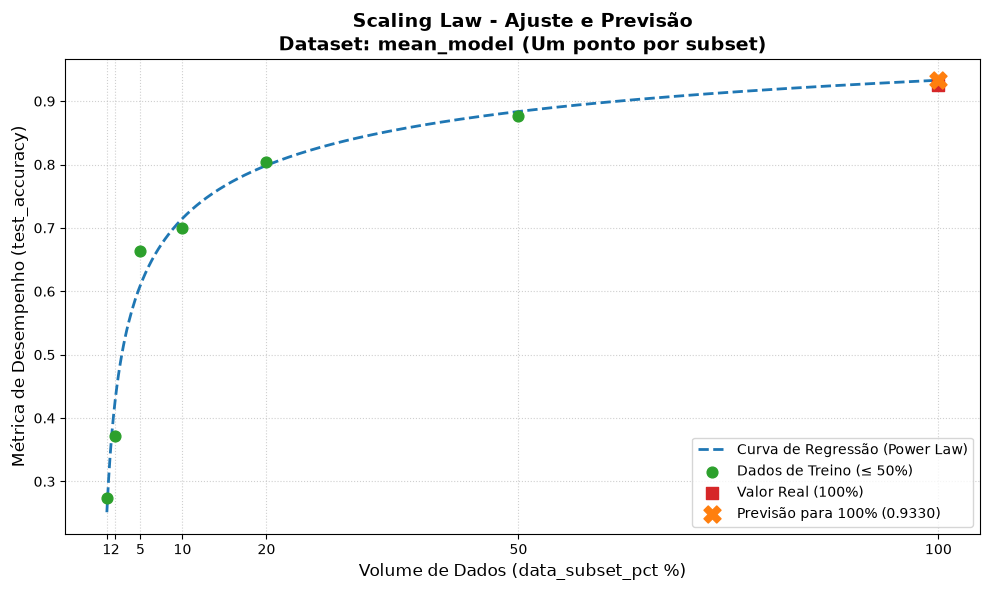

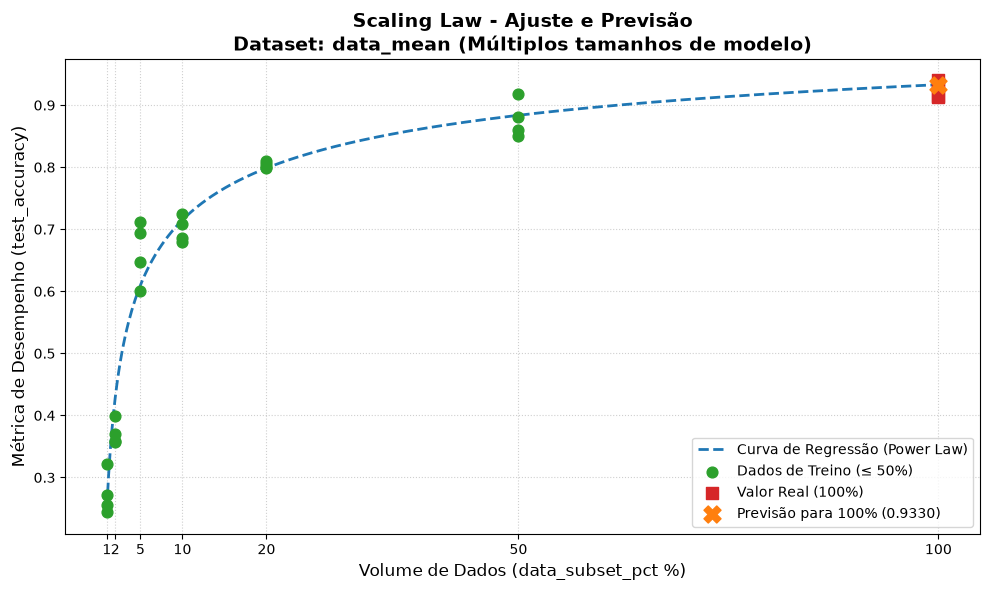

In [16]:
def plotar_curva_escala(df, nome_dataset):
    df = df.copy()

    # Garantir que temos a taxa de erro para o ajuste matemático
    if 'test_error_rate' not in df.columns:
        df['test_error_rate'] = 1.0 - df['test_accuracy']

    # Separar os dados de Treino (<= 50%) e Validação (== 100%)
    df_train = df[df['data_subset_pct'] <= 50]
    df_test = df[df['data_subset_pct'] == 100]

    X_train = df_train['data_subset_pct'].values
    y_train_error = df_train['test_error_rate'].values
    y_train_acc = df_train['test_accuracy'].values

    X_test = df_test['data_subset_pct'].values
    y_test_acc = df_test['test_accuracy'].values

    try:
        popt, _ = curve_fit(scaling_law, X_train, y_train_error, p0=[1.0, 0.5, 0.0], maxfev=10000)
        a_opt, b_opt, c_opt = popt
        X_line = np.linspace(1, 100, 500)
        Y_line_acc = 1.0 - scaling_law(X_line, a_opt, b_opt, c_opt)

        pred_100_acc = 1.0 - scaling_law(100, a_opt, b_opt, c_opt)

        plt.figure(figsize=(10, 6))
        plt.plot(X_line, Y_line_acc, color='#1f77b4', linestyle='--', linewidth=2, label='Curva de Regressão (Power Law)')
        plt.scatter(X_train, y_train_acc, color='#2ca02c', s=60, zorder=5, label='Dados de Treino (≤ 50%)')
        plt.scatter(X_test, y_test_acc, color='#d62728', marker='s', s=80, zorder=5, label='Valor Real (100%)')
        plt.scatter(100, pred_100_acc, color='#ff7f0e', marker='X', s=150, zorder=6, label=f'Previsão para 100% ({pred_100_acc:.4f})')
        plt.title(f'Scaling Law - Ajuste e Previsão\nDataset: {nome_dataset}', fontsize=14, fontweight='bold')
        plt.xlabel('Volume de Dados (data_subset_pct %)', fontsize=12)
        plt.ylabel('Métrica de Desempenho (test_accuracy)', fontsize=12)
        plt.xticks([1, 2, 5, 10, 20, 50, 100])
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='lower right', fontsize=10)

        plt.tight_layout()
        plt.show()

    except RuntimeError as e:
        print(f"Não foi possível gerar o gráfico para {nome_dataset}: {e}")

# Substitua 'mean_model' e 'data_mean' pelas suas variáveis reais se necessário
plotar_curva_escala(mean_model, "mean_model (Um ponto por subset)")
plotar_curva_escala(data_mean, "data_mean (Múltiplos tamanhos de modelo)")

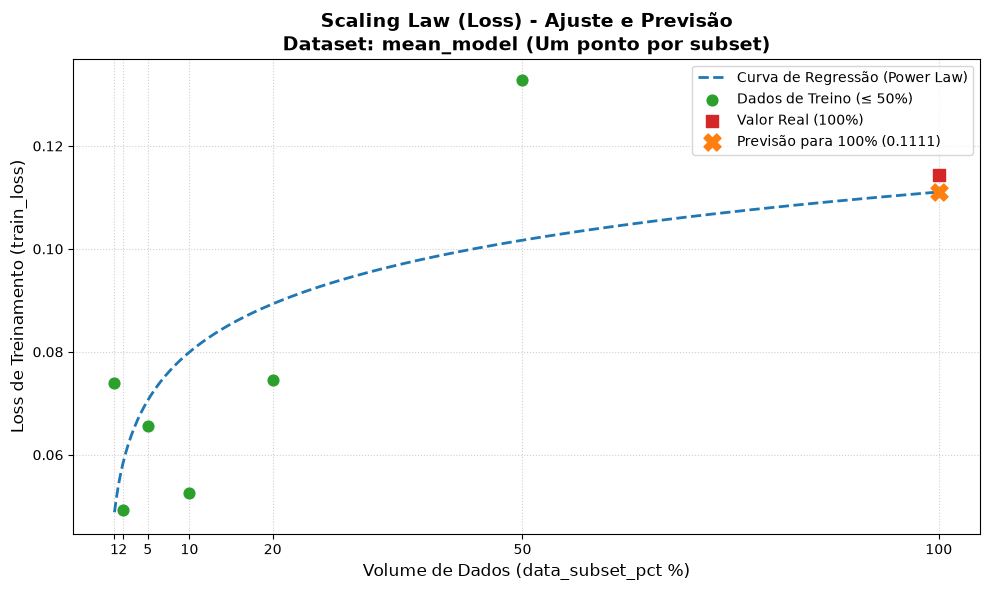

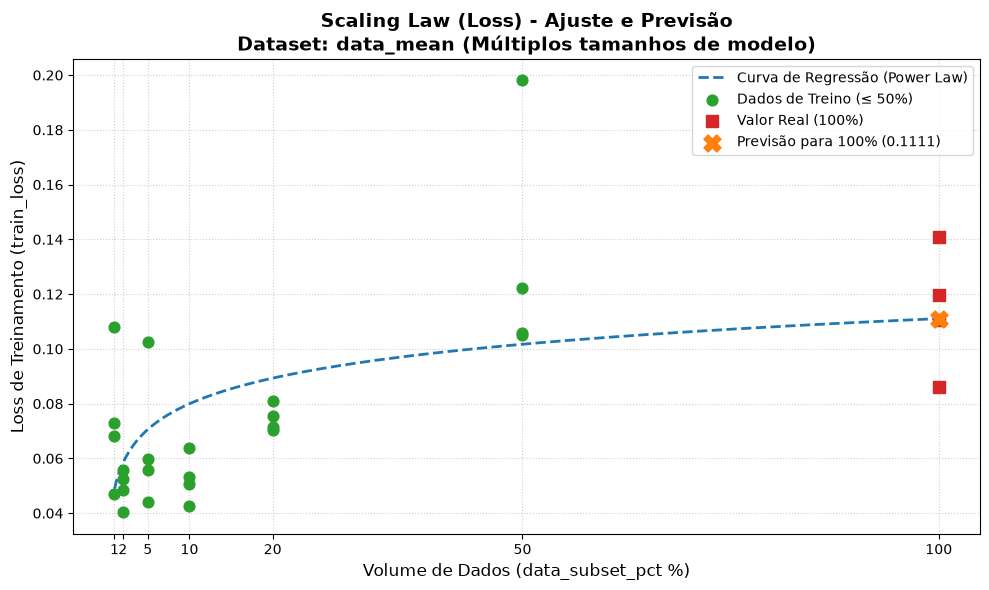

In [17]:
def plotar_curva_escala_loss(df, nome_dataset):
    df = df.copy()

    # Separar os dados de Treino (<= 50%) e Validação (== 100%)
    df_train = df[df['data_subset_pct'] <= 50]
    df_test = df[df['data_subset_pct'] == 100]

    X_train = df_train['data_subset_pct'].values
    y_train_loss = df_train['train_loss'].values

    X_test = df_test['data_subset_pct'].values
    y_test_loss = df_test['train_loss'].values

    # Ajuste dos parâmetros por Mínimos Quadrados Não Lineares
    try:
        # Aplicamos o curve_fit diretamente na train_loss agora
        popt, _ = curve_fit(scaling_law, X_train, y_train_loss, p0=[1.0, 0.5, 0.0], maxfev=10000)
        a_opt, b_opt, c_opt = popt

        # Criar pontos no eixo X para desenhar uma linha suave de 1% até 100%
        X_line = np.linspace(1, 100, 500)
        # Previsão da linha de regressão
        Y_line_loss = scaling_law(X_line, a_opt, b_opt, c_opt)

        # Previsão exata para o ponto de 100%
        pred_100_loss = scaling_law(100, a_opt, b_opt, c_opt)

        # --- Construção do Gráfico ---
        plt.figure(figsize=(10, 6))

        # 1. Linha da Regressão (Previsão do Modelo)
        plt.plot(X_line, Y_line_loss, color='#1f77b4', linestyle='--', linewidth=2, label='Curva de Regressão (Power Law)')

        # 2. Pontos de Treinamento (usados no ajuste)
        plt.scatter(X_train, y_train_loss, color='#2ca02c', s=60, zorder=5, label='Dados de Treino (≤ 50%)')

        # 3. Ponto Real em 100% (Alvo da validação)
        plt.scatter(X_test, y_test_loss, color='#d62728', marker='s', s=80, zorder=5, label='Valor Real (100%)')

        # 4. Ponto Previsto em 100% (Marcador 'X')
        plt.scatter(100, pred_100_loss, color='#ff7f0e', marker='X', s=150, zorder=6, label=f'Previsão para 100% ({pred_100_loss:.4f})')

        # Customização do Gráfico
        plt.title(f'Scaling Law (Loss) - Ajuste e Previsão\nDataset: {nome_dataset}', fontsize=14, fontweight='bold')
        plt.xlabel('Volume de Dados (data_subset_pct %)', fontsize=12)
        plt.ylabel('Loss de Treinamento (train_loss)', fontsize=12)

        # Forçar o eixo X a mostrar os seus subconjuntos específicos
        plt.xticks([1, 2, 5, 10, 20, 50, 100])
        plt.grid(True, linestyle=':', alpha=0.6)

        # Mudamos a legenda para o topo à direita, já que a curva cai da esquerda para a direita
        plt.legend(loc='upper right', fontsize=10)

        plt.tight_layout()
        plt.show()

    except RuntimeError as e:
        print(f"Não foi possível gerar o gráfico para {nome_dataset}: {e}")

# Executando para os dois datasets
plotar_curva_escala_loss(mean_model, "mean_model (Um ponto por subset)")
plotar_curva_escala_loss(data_mean, "data_mean (Múltiplos tamanhos de modelo)")

---